<a href="https://colab.research.google.com/github/faezeheshvandi/AI-2025/blob/main/MiniProject3%20/%20MP3_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Q1

# Data Generation

In [ ]:
def h(x):
    """The target function to approximate."""
    return np.exp(-np.pi * x**2) + x * np.sin(np.pi * x)

# Generate 300 input and output data points
X_train = np.linspace(-1, 1, 300).reshape(-1, 1)
Y_train = h(X_train)

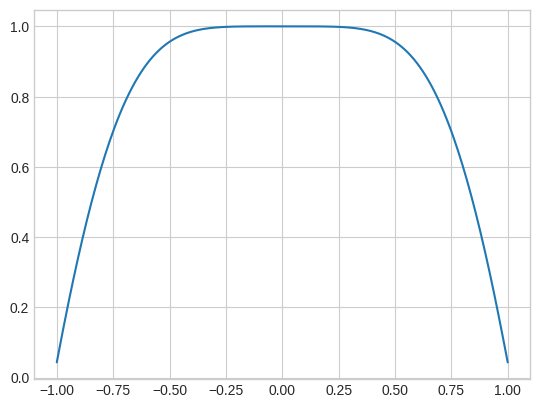

In [ ]:
plt.plot(X_train, Y_train)
plt.show()

# Define the Fuzzy System Structure

In [ ]:
def gaussian_mf(x, center, width):
    """Calculates the degree of membership using a Gaussian function."""
    # Use a small epsilon to prevent division by zero
    return np.exp(-((x - center)**2) / (2 * width**2 + 1e-9))

In [ ]:
class FuzzySystem:
    def __init__(self, num_rules, learning_rate=0.01):
        self.num_rules = num_rules
        self.lr = learning_rate

        # Initialize parameters
        # Input membership function centers are evenly distributed across the domain
        self.input_centers = np.linspace(-1, 1, num_rules)
        # All input membership function widths are initially the same
        self.input_widths = np.full(num_rules, 0.2)
        # The output of each rule (consequent) is initially zero
        self.output_levels = np.zeros(num_rules)

    def predict(self, x):
        """Predicts the output for a given input x."""
        # Calculate the firing strength for each rule
        firing_strengths = gaussian_mf(x, self.input_centers, self.input_widths)

        # Calculate the total sum of firing strengths
        total_strength = np.sum(firing_strengths)

        if total_strength == 0:
            return 0 # To prevent division by zero

        # Calculate the final output using the weighted average formula
        weighted_sum = np.sum(firing_strengths * self.output_levels)
        return weighted_sum / total_strength

    def train(self, X, Y_target, epochs=100):
        """Trains the system parameters using Gradient Descent."""
        for epoch in range(epochs):
            total_epoch_error = 0
            for x, y_true in zip(X, Y_target):
                # --- Forward Pass ---
                firing_strengths = gaussian_mf(x, self.input_centers, self.input_widths)
                sum_strengths = np.sum(firing_strengths)

                if sum_strengths == 0:
                    continue

                y_pred = np.sum(firing_strengths * self.output_levels) / sum_strengths

                # --- Backward Pass (Gradient Calculation and Update) ---
                error = y_true - y_pred
                total_epoch_error += error**2

                # The gradient for each parameter is calculated using the chain rule
                # dE/d_param = dE/dy_pred * dy_pred/d_param

                # Update rule consequents (output_levels)
                grad_output_levels = -error * (firing_strengths / sum_strengths)
                self.output_levels -= self.lr * grad_output_levels

                # Update membership function centers (input_centers)
                term1 = (self.output_levels - y_pred) / sum_strengths
                term2 = firing_strengths * (x - self.input_centers) / (self.input_widths**2 + 1e-9)
                grad_centers = -error * term1 * term2
                self.input_centers -= self.lr * grad_centers

                # Update membership function widths (input_widths)
                term3 = firing_strengths * (x - self.input_centers)**2 / (self.input_widths**3 + 1e-9)
                grad_widths = -error * term1 * term3
                self.input_widths -= self.lr * grad_widths

            if (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1}/{epochs}, MSE: {total_epoch_error[0]/len(X):.4f}")


# Create and Train the System

In [ ]:
# We assume 8 rules are sufficient (answering the minimum rules question)
num_rules = 8
fs = FuzzySystem(num_rules=num_rules, learning_rate=0.04)

print("Starting training...")
fs.train(X_train, Y_train, epochs=200)
print("Training finished.")

Starting training...
Epoch 20/200, MSE: 0.0049
Epoch 40/200, MSE: 0.0023
Epoch 60/200, MSE: 0.0014
Epoch 80/200, MSE: 0.0010
Epoch 100/200, MSE: 0.0008
Epoch 120/200, MSE: 0.0007
Epoch 140/200, MSE: 0.0006
Epoch 160/200, MSE: 0.0005
Epoch 180/200, MSE: 0.0005
Epoch 200/200, MSE: 0.0004
Training finished.


# Evaluate and Display Results

In [ ]:
# Predict over the entire domain for plotting
X_test = np.linspace(-1, 1, 400).reshape(-1, 1)
Y_pred = np.array([fs.predict(x) for x in X_test])

In [ ]:
# Calculate the final error
final_error = np.mean((h(X_test) - Y_pred)**2)
print(final_error)
print(f"\nFinal Mean Squared Error (MSE): {final_error:.4f}")
print(f"Is error less than 0.1? {'Yes' if final_error < 0.1 else 'No'}")

0.13748375699846743

Final Mean Squared Error (MSE): 0.1375
Is error less than 0.1? No


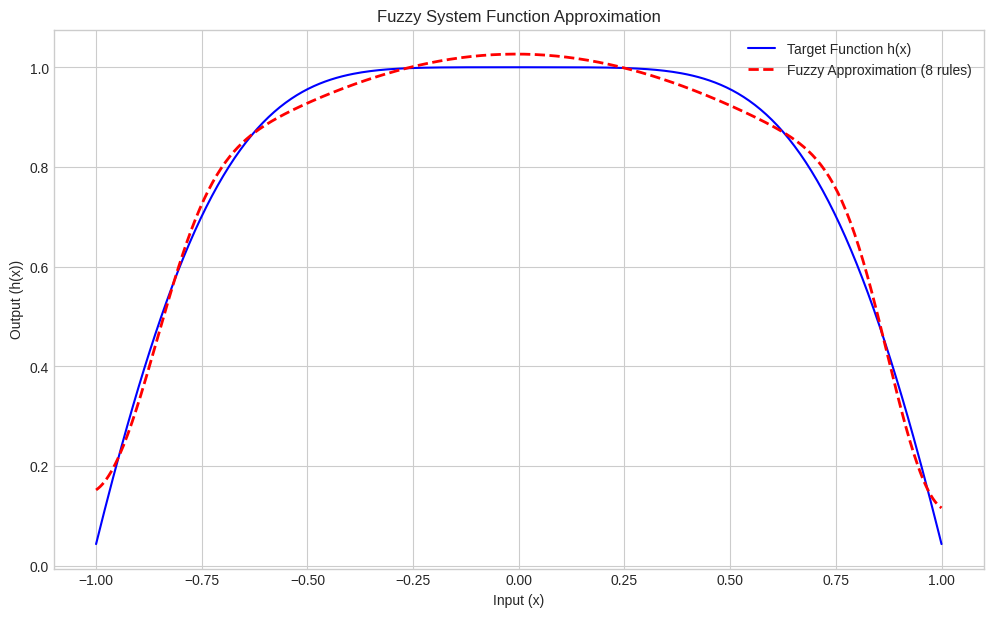

In [ ]:
# Plot the results
plt.figure(figsize=(12, 7))
plt.plot(X_train, Y_train, 'b-', label='Target Function h(x)')
plt.plot(X_test, Y_pred, 'r--', linewidth=2, label=f'Fuzzy Approximation ({num_rules} rules)')
plt.title('Fuzzy System Function Approximation')
plt.xlabel('Input (x)')
plt.ylabel('Output (h(x))')
plt.legend()
plt.grid(True)
plt.show()

# Q2

# Target Function

In [ ]:
def g(x1, x2):
    """The target function to be approximated."""
    return 1 / (3 + x1 + x2)

# Membership Function

In [ ]:
def triangular_mf(x, center, h):
    """Triangular membership function."""
    # The base of the triangle is 2*h, from center-h to center+h
    return np.maximum(0, 1 - np.abs(x - center) / h)

# System 1: First-Order Bound, Mean Defuzzifier

In [ ]:
class FuzzySystem1:
    def __init__(self):
        self.h = 0.2
        # 11 points from -1 to 1: [-1, -0.8, ..., 0.8, 1]
        self.centers = np.linspace(-1, 1, int(2 / self.h) + 1)
        self.num_rules_dim = len(self.centers)
        # Pre-calculate consequent values
        self.consequents = np.zeros((self.num_rules_dim, self.num_rules_dim))
        for i in range(self.num_rules_dim):
            for j in range(self.num_rules_dim):
                self.consequents[i, j] = g(self.centers[i], self.centers[j])

    def predict(self, x1, x2):
        """Predicts output using weighted average defuzzifier."""
        firing_strengths = np.zeros_like(self.consequents)
        for i in range(self.num_rules_dim):
            mu_x1 = triangular_mf(x1, self.centers[i], self.h)
            for j in range(self.num_rules_dim):
                mu_x2 = triangular_mf(x2, self.centers[j], self.h)
                # Using product for AND operator
                firing_strengths[i, j] = mu_x1 * mu_x2

        total_strength = np.sum(firing_strengths)
        if total_strength == 0:
            return 0

        weighted_sum = np.sum(firing_strengths * self.consequents)
        return weighted_sum / total_strength

# System 2: Second-Order Bound, Max Defuzzifier

In [ ]:
class FuzzySystem2:
    def __init__(self):
        self.h = 2/3.0
        # 4 points from -1 to 1: [-1, -1/3, 1/3, 1]
        self.centers = np.linspace(-1, 1, 4)
        self.num_rules_dim = len(self.centers)
        # Pre-calculate consequent values
        self.consequents = np.zeros((self.num_rules_dim, self.num_rules_dim))
        for i in range(self.num_rules_dim):
            for j in range(self.num_rules_dim):
                self.consequents[i, j] = g(self.centers[i], self.centers[j])

    def predict(self, x1, x2):
        """Predicts output using max (winner-take-all) defuzzifier."""
        firing_strengths = np.zeros_like(self.consequents)
        for i in range(self.num_rules_dim):
            mu_x1 = triangular_mf(x1, self.centers[i], self.h)
            for j in range(self.num_rules_dim):
                mu_x2 = triangular_mf(x2, self.centers[j], self.h)
                # Using product for AND operator
                firing_strengths[i, j] = mu_x1 * mu_x2

        # Find the rule with the maximum firing strength
        winner_indices = np.unravel_index(np.argmax(firing_strengths), firing_strengths.shape)
        return self.consequents[winner_indices]


# Visualization

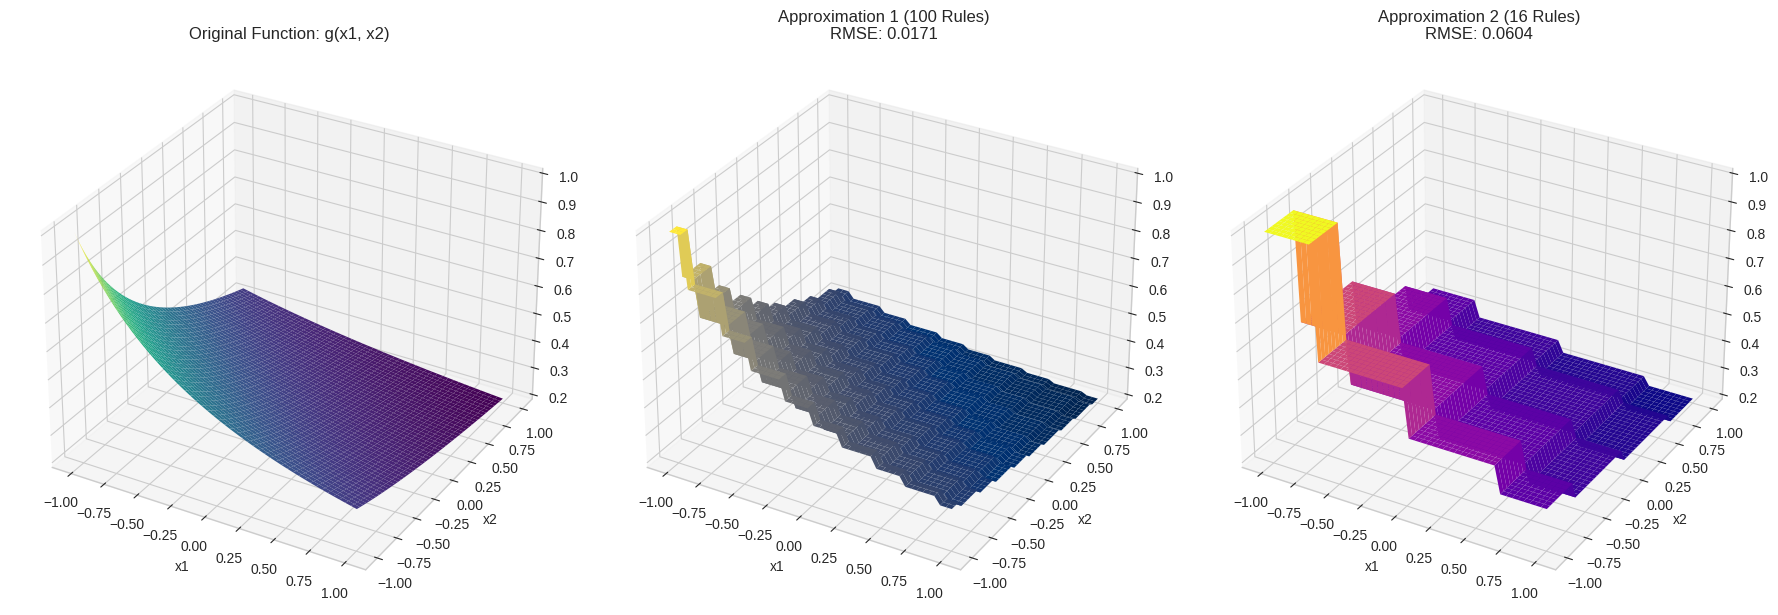

In [ ]:
fig = plt.figure(figsize=(18, 6))

# Plot 1: Original Function
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_true, cmap='viridis')
ax1.set_title('Original Function: g(x1, x2)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')

# Plot 2: First-Order Bound Approximation
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_pred1, cmap='cividis')
ax2.set_title(f'Approximation 1 (100 Rules)\nRMSE: {rmse1:.4f}')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')

# Plot 3: Second-Order Bound Approximation
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X, Y, Z_pred2, cmap='plasma')
ax3.set_title(f'Approximation 2 (16 Rules)\nRMSE: {rmse2:.4f}')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate and print errors
error1 = np.max(np.abs(Z_true - Z_fs1))
error2 = np.max(np.abs(Z_true - Z_fs2))
print(f"Maximum absolute error for System 1 (Mean): {error1:.4f}")
print(f"Maximum absolute error for System 2 (Max):  {error2:.4f}")

Maximum absolute error for System 1 (Mean): 0.0122
Maximum absolute error for System 2 (Max):  0.3951


# Q3

# Define Necessary Functions

In [ ]:
def generate_mackey_glass(n_points=1500, a=0.2, b=0.1, tau=17, initial_val=1.2, delta_t=1):
    """Generates the Mackey-Glass time series."""
    x = np.zeros(n_points)
    x[0] = initial_val
    for t in range(1, n_points):
        if t < tau:
            x[t] = x[t-1] + delta_t * (a * x[0] / (1 + x[0]**10) - b * x[t-1])
        else:
            x[t] = x[t-1] + delta_t * (a * x[t-tau] / (1 + x[t-tau]**10) - b * x[t-1])
    return x

In [ ]:
def create_dataset(series, past_lags, future_step):
    """
    Creates input-output pairs from a time series.
    For this problem, we'll use 2 inputs: [x(t-6), x(t)] to predict x(t+6).
    """
    X, y = [], []
    max_lag = max(past_lags)
    for i in range(max_lag, len(series) - future_step):
        input_vector = [series[i - lag] for lag in past_lags]
        output_value = series[i + future_step]
        X.append(input_vector)
        y.append(output_value)
    return np.array(X), np.array(y)

# Fuzzy System Using The Lookup Table Method

In [ ]:
class LookupTableFuzzySystem:
    """
    Implements a fuzzy system using the lookup table method.
    This implementation is for a 2-input, 1-output system for clarity.
    """
    def __init__(self, quantization_levels=10):
        self.levels = quantization_levels
        self.table_values = np.zeros((self.levels, self.levels))
        self.table_counts = np.zeros((self.levels, self.levels))
        self.input_min = None
        self.input_max = None
        self.input_range = None

    def _get_indices(self, x):
        """Finds the grid cell indices for a given 2D input vector x."""
        if self.input_range is None:
            raise ValueError("System has not been trained yet.")

        # Normalize input to [0, levels-1]
        norm_x = (x - self.input_min) / self.input_range
        indices = np.floor(norm_x * (self.levels - 1))
        return np.clip(indices, 0, self.levels - 1).astype(int)

    def build_table(self, X_train, y_train):
        """Step 1 & 2: Build the lookup table from training data."""
        self.input_min = X_train.min(axis=0)
        self.input_max = X_train.max(axis=0)
        self.input_range = self.input_max - self.input_min

        for x_sample, y_sample in zip(X_train, y_train):
            idx1, idx2 = self._get_indices(x_sample)
            self.table_values[idx1, idx2] += y_sample
            self.table_counts[idx1, idx2] += 1

        # Calculate the average value for each cell
        non_zero_counts = self.table_counts > 0
        self.table_values[non_zero_counts] /= self.table_counts[non_zero_counts]
        print(f"Table built. {np.sum(non_zero_counts)} of {self.levels**2} cells are filled.")

    def fill_empty_cells(self, max_iterations=20):
        """Step 3: Fill empty cells by averaging neighbors."""
        print("Filling empty cells...")
        filled_mask = self.table_counts > 0

        for iteration in range(max_iterations):
            newly_filled = 0
            for i in range(self.levels):
                for j in range(self.levels):
                    if not filled_mask[i, j]:
                        neighbor_sum = 0
                        neighbor_count = 0
                        # Check 8 neighbors
                        for di in [-1, 0, 1]:
                            for dj in [-1, 0, 1]:
                                if di == 0 and dj == 0: continue
                                ni, nj = i + di, j + dj
                                if 0 <= ni < self.levels and 0 <= nj < self.levels and filled_mask[ni, nj]:
                                    neighbor_sum += self.table_values[ni, nj]
                                    neighbor_count += 1

                        if neighbor_count > 0:
                            self.table_values[i, j] = neighbor_sum / neighbor_count
                            filled_mask[i, j] = True
                            newly_filled += 1
            if newly_filled == 0:
                print(f"Filling complete after {iteration+1} iterations.")
                break

        if np.sum(~filled_mask) > 0:
            print(f"Warning: {np.sum(~filled_mask)} cells remain empty.")


    def predict(self, X_test):
        """Step 4: Predict output for new data using bilinear interpolation."""
        predictions = []
        for x_sample in X_test:
            # Normalize input to a float index
            norm_x = (x_sample - self.input_min) / self.input_range
            float_indices = norm_x * (self.levels - 1)

            # Find the 4 neighboring grid points (bilinear interpolation)
            i_low, j_low = np.floor(float_indices).astype(int)
            i_high, j_high = np.ceil(float_indices).astype(int)

            # Ensure indices are within bounds
            i_low, i_high = np.clip([i_low, i_high], 0, self.levels - 1)
            j_low, j_high = np.clip([j_low, j_high], 0, self.levels - 1)

            # Get values from the 4 corners of the cell
            q11 = self.table_values[i_low, j_low]
            q21 = self.table_values[i_high, j_low]
            q12 = self.table_values[i_low, j_high]
            q22 = self.table_values[i_high, j_high]

            # Calculate interpolation weights (distances)
            dx = float_indices[0] - i_low
            dy = float_indices[1] - j_low

            # Interpolate in x-direction
            r1 = q11 * (1 - dx) + q21 * dx
            r2 = q12 * (1 - dx) + q22 * dx

            # Interpolate in y-direction
            prediction = r1 * (1 - dy) + r2 * dy
            predictions.append(prediction)

        return np.array(predictions)

# Main Execution

In [ ]:
# 1. Generate Data
mg_series = generate_mackey_glass(n_points=2000, tau=17)
# Use inputs x(t-6) and x(t) to predict x(t+6)
past_lags = [6, 0] # Lags relative to t
future_step = 6
X, y = create_dataset(mg_series, past_lags, future_step)

In [ ]:
# 2. Split data for training and testing
split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
# 3. Create, build, and fill the fuzzy system
fs = LookupTableFuzzySystem(quantization_levels=15)
fs.build_table(X_train, y_train)
fs.fill_empty_cells()

Table built. 124 of 225 cells are filled.
Filling empty cells...
Filling complete after 2 iterations.


In [ ]:
# 4. Make predictions
y_pred = fs.predict(X_test)

# Visualization

In [ ]:
# 5. Show Results
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(f"\nPrediction Results:")
print(f"  - Root Mean Squared Error (RMSE): {rmse:.4f}")


Prediction Results:
  - Root Mean Squared Error (RMSE): 0.0792


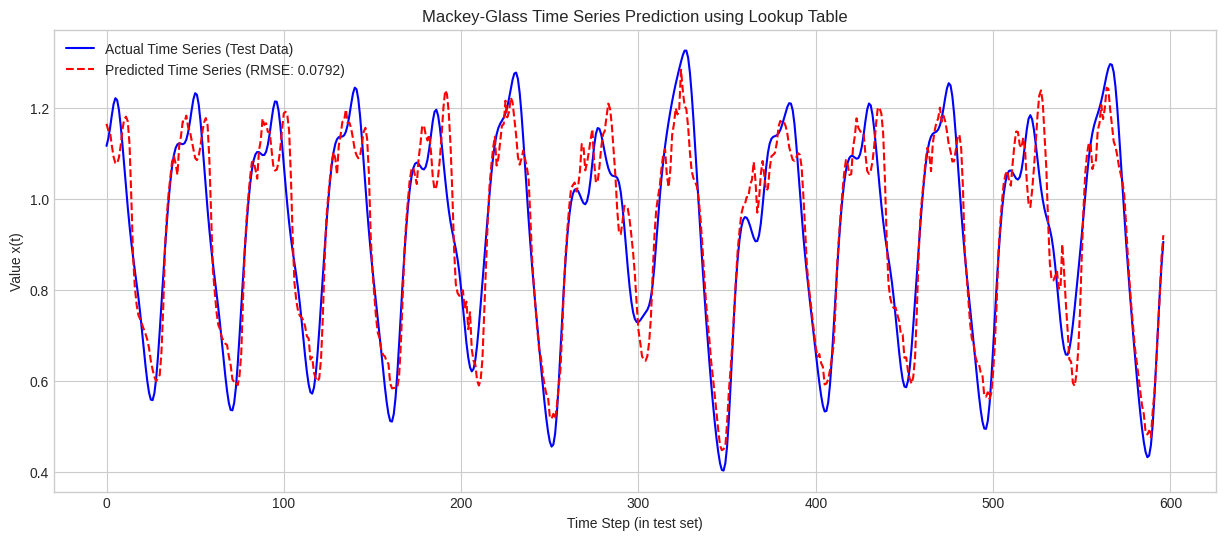

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test, 'b-', label='Actual Time Series (Test Data)')
plt.plot(y_pred, 'r--', label=f'Predicted Time Series (RMSE: {rmse:.4f})')
plt.title('Mackey-Glass Time Series Prediction using Lookup Table')
plt.xlabel('Time Step (in test set)')
plt.ylabel('Value x(t)')
plt.legend()
plt.grid(True)
plt.show()